# Libraries:

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data:

In [3]:
df = pd.read_csv("../data/ecommerce_user_segmentation.csv")

df.head()

,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns,Segment_Label
0,CUST00001,51,13,1560,113,56,14.766242,33,828,1,28,17.629489,8,Silver
1,CUST00002,134,5,3,26,7,5.409044,2,60,0,4,23.024216,9,Iron
2,CUST00003,55,15,235,57,37,5.082231,11,710,1,17,28.391939,16,Copper
3,CUST00004,46,11,1293,191,48,18.936486,20,1223,0,17,15.192267,0,Silver
4,CUST00005,21,30,3602,239,90,26.461395,37,1892,0,57,11.427460,8,Gold


# Dataset Overview:

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Customer_ID           10000 non-null  str    
 1   Recency               10000 non-null  int64  
 2   Frequency             10000 non-null  int64  
 3   Monetary              10000 non-null  int64  
 4   Avg_Order_Value       10000 non-null  int64  
 5   Session_Count         10000 non-null  int64  
 6   Avg_Session_Duration  10000 non-null  float64
 7   Pages_Viewed          10000 non-null  int64  
 8   Clicks                10000 non-null  int64  
 9   Campaign_Response     10000 non-null  int64  
 10  Wishlist_Adds         10000 non-null  int64  
 11  Cart_Abandon_Rate     10000 non-null  float64
 12  Returns               10000 non-null  int64  
 13  Segment_Label         10000 non-null  str    
dtypes: float64(2), int64(10), str(2)
memory usage: 1.1 MB


The dataset contains 10,000 customer records with 13 behavioral and transactional features, including Recency, Frequency, Monetary value, session activity, and engagement metrics. All columns contain 10,000 non-null values, indicating that the dataset does not contain any missing values and is clean for further analysis.The column Customer_ID is a string identifier used only to uniquely identify customers and will not be used as a predictive feature in the model, so we will remove this column.



In [5]:
df.describe()

,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,48.665400,28.783000,1938.394600,146.599900,55.915800,15.444645,33.99840,1211.465100,0.416700,28.618300,17.653052,7.268800
std,37.818734,23.133669,2327.840348,87.564246,43.551484,8.133285,21.14206,1058.875362,0.493037,23.544257,10.013803,5.623247
min,1.000000,0.000000,0.000000,10.000000,0.000000,1.000433,1.00000,50.000000,0.000000,0.000000,0.007050,0.000000
25%,22.000000,10.000000,269.000000,79.000000,22.000000,9.515457,18.00000,451.750000,0.000000,11.000000,10.829601,3.000000
50%,40.000000,20.000000,1022.000000,135.000000,44.000000,14.305176,30.00000,871.000000,0.000000,21.000000,15.908491,6.000000
75%,63.000000,40.000000,2825.250000,196.000000,75.000000,19.725305,46.00000,1518.000000,1.000000,41.000000,22.769516,11.000000
max,179.000000,99.000000,9995.000000,399.000000,199.000000,39.995729,99.00000,4998.000000,1.000000,99.000000,49.994254,24.000000


The dataset shows wide variation in customer behavior. For example, the Monetary value ranges from 0 to 9995, and Frequency ranges from 0 to 99, indicating that some customers purchase very frequently while others rarely engage with the platform.The difference between mean and median values in several features (such as Monetary and Clicks) indicates that the dataset may contain skewed distributions or high-value customers, which is common in real-world e-commerce datasets.

# EDA(Exploratory Data Analysis):

## 1.Feature Distribution Analysis:
### why we are doing this?
Before training models, we analyze how the features are distributed. This helps us:

Detect skewed data

Identify outliers

Understand customer behavior patterns

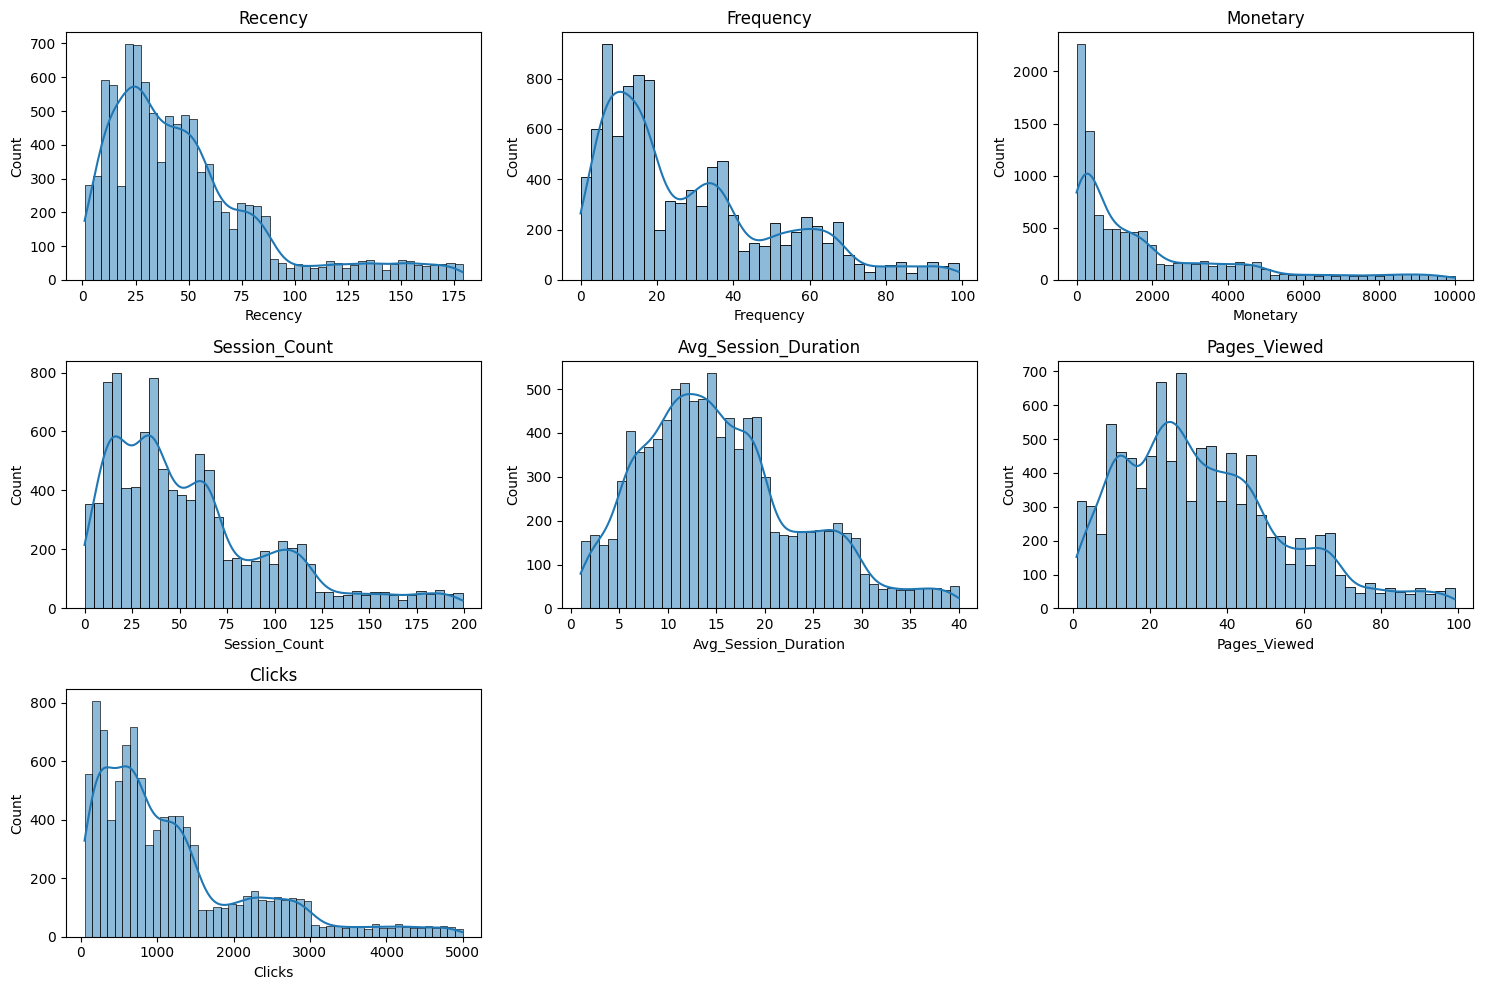

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15,10))

features = [
    "Recency","Frequency","Monetary",
    "Session_Count","Avg_Session_Duration",
    "Pages_Viewed","Clicks"
]

for i, col in enumerate(features,1):
    plt.subplot(3,3,i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

## Insights:
1.The distribution plots show that most behavioral features such as Frequency, Session_Count, Pages_Viewed, and Clicks are right-skewed, indicating that a small group of customers generates significantly higher engagement compared to the majority.

2.The Monetary feature is highly right-skewed, suggesting that while many customers spend small amounts, a limited number of customers contribute very high purchase values, which is typical in e-commerce datasets.

3.The Recency distribution indicates that many customers interacted recently, while fewer customers show very high recency values, which may represent inactive or potentially churned users.

4.Engagement metrics such as Avg_Session_Duration and Pages_Viewed show moderate variation, indicating different levels of browsing behavior among users on the platform.

## 2. Correlation Heatmap

This helps us identify:

Which features influence customer spending

Which behaviors are related to engagement

Which variables might cause multicollinearity

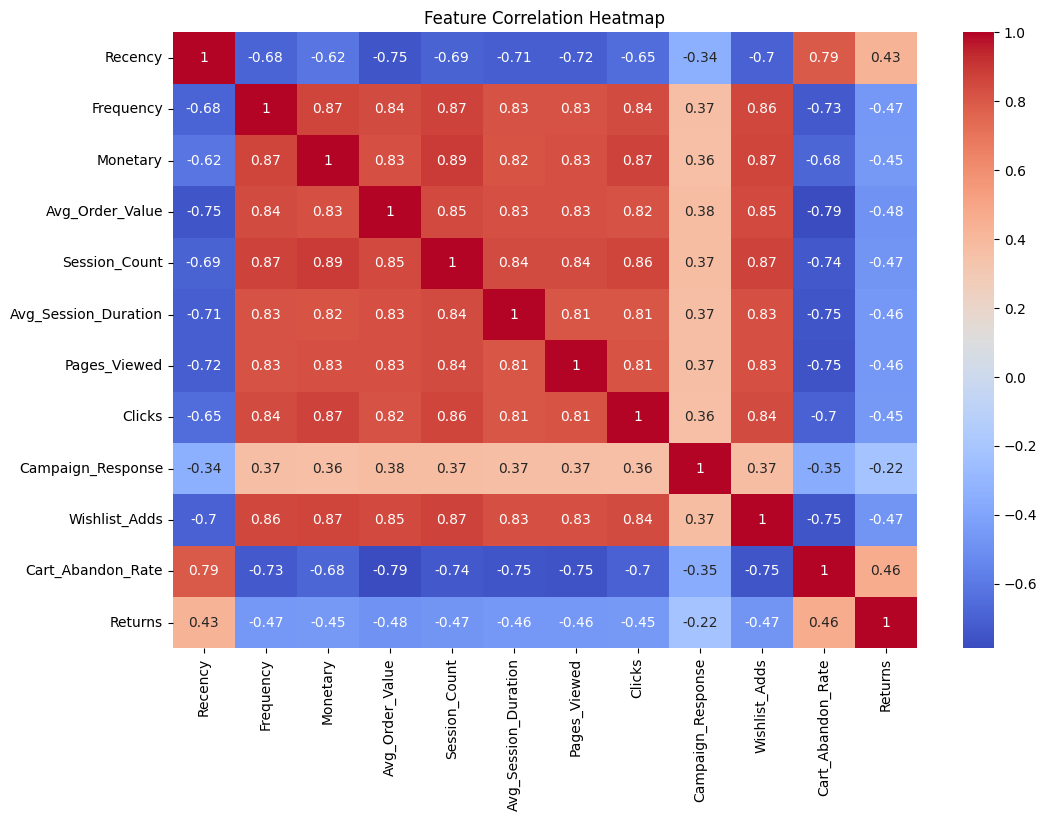

In [7]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=["int64","float64"])

corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.show()

The dataset contains both numeric and categorical features. Correlation calculations only work with numeric data, so we filters the dataset to include only integer and floating-point columns.

## Insights:
1. Customer Engagement Drives Spending

Features such as Frequency, Session_Count, Clicks, and Avg_Order_Value show strong positive correlations with Monetary value (0.83–0.89). This indicates that highly engaged customers tend to spend significantly more, making engagement metrics strong predictors for Customer Lifetime Value (LTV).

2. Recency Indicates Churn Risk

Recency shows strong negative correlations with key engagement features such as Frequency (-0.68), Monetary (-0.62), and Session_Count (-0.69). This suggests that customers who have not interacted recently are less active and may be at risk of churn.

3. Cart Abandonment as a Warning Signal

Cart_Abandon_Rate is strongly negatively correlated with purchasing and engagement behaviors. Customers with higher abandonment rates tend to show lower purchase frequency and spending, indicating potential conversion or retention issues.

4. Engagement Features Are Highly Related

Features such as Session_Count, Pages_Viewed, Clicks, and Avg_Session_Duration are strongly correlated, representing a common customer engagement dimension. This suggests these variables collectively capture user interaction behavior on the platform.

5. Campaign Response Has Limited Impact

Campaign_Response shows relatively weak correlations with most behavioral metrics, suggesting marketing campaigns alone may not strongly influence long-term engagement or spending behavior.

## 3. RFM Scatter Plot:
This help us:

Understand customer behavior

Identify valuable and at-risk customers

Support building predictive modeling

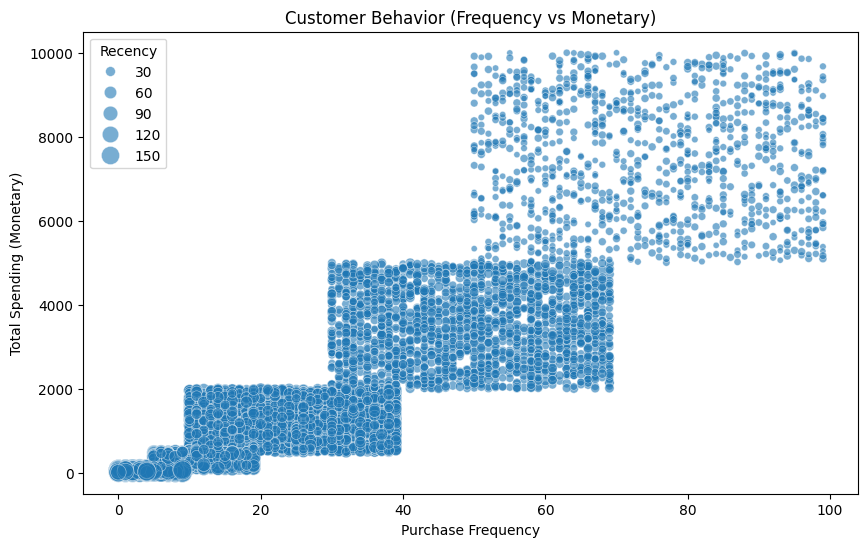

In [8]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x=df["Frequency"],
    y=df["Monetary"],
    size=df["Recency"],
    sizes=(20,200),
    alpha=0.6
)

plt.title("Customer Behavior (Frequency vs Monetary)")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Spending (Monetary)")

plt.show()

## Insights:

#### 1. Engagement Drives Spending:
- Customers with high purchase frequency (x-axis) tend to have higher monetary value (y-axis)
- Strong positive correlation (0.87) confirms that frequent buyers are valuable customers
- The density of points along the diagonal shows consistent relationship

#### 2. Recency as Risk Indicator (bubble size):
- Larger bubbles (high recency values) are scattered more toward lower spending and frequency
- Indicates that customers who haven't interacted recently spend less
- Recent, high-frequency customers (small bubbles, right side) are most valuable

#### 3. Customer Segmentation Opportunity:
- High-frequency, high-spending customers (top-right): VIP segment - prioritize retention
- Low-frequency, low-spending customers (bottom-left): At-risk segment - need re-engagement
- Mixed behaviors reveal distinct customer tiers for targeted strategies

#### 4. Outlier Detection:
- Some customers show high frequency but low monetary value: may indicate low average order value
- Some show high spending despite low frequency: likely high-value, occasional buyers
- These outliers represent different customer archetypes requiring different strategies this is the insights from RFM scatter plot now tell me the next step what should be removed or not or the data is good we can proceed with feature engineering part 

## Feature Engineering:


In [9]:
import sys
import os
sys.path.append(os.path.abspath("../"))
from src.feature_engineering import create_features
df = create_features(df)
df.head()

,Customer_ID,Recency,Frequency,Monetary,Avg_Order_Value,Session_Count,Avg_Session_Duration,Pages_Viewed,Clicks,Campaign_Response,Wishlist_Adds,Cart_Abandon_Rate,Returns,Segment_Label,Clicks_per_Page,Wishlist_Conversion,Engagement_Score,Churn
0,CUST00001,51,13,1560,113,56,14.766242,33,828,1,28,17.629489,8,Silver,24.352941,0.448276,826.909530,0
1,CUST00002,134,5,3,26,7,5.409044,2,60,0,4,23.024216,9,Iron,20.000000,1.000000,37.863306,1
2,CUST00003,55,15,235,57,37,5.082231,11,710,1,17,28.391939,16,Copper,59.166667,0.833333,188.042559,0
3,CUST00004,46,11,1293,191,48,18.936486,20,1223,0,17,15.192267,0,Silver,58.238095,0.611111,908.951352,0
4,CUST00005,21,30,3602,239,90,26.461395,37,1892,0,57,11.427460,8,Gold,49.789474,0.517241,2381.525550,0


## Data Preprocessing:

In [10]:
from src.data_preprocessing import preprocess_data

X_train, X_test, y_train, y_test = preprocess_data(df)




In [11]:
print(X_train.shape)
print(X_test.shape)

(8000, 15)
(2000, 15)


## Model Scores:


In [12]:
import sys
sys.path.append("../src")

from train_churn_model import train_churn_model
from train_ltv_model import train_ltv_model

churn_score = train_churn_model()
ltv_score = train_ltv_model()

print("Churn Model Accuracy:", churn_score)
print("LTV Model R2 Score:", ltv_score)

Churn Model Accuracy: 0.954
LTV Model R2 Score: 0.9012008905410767
